In [1]:
# input
rep_info_file = "../data/repId-numSeqRep-numPredSeqRep-numAnnoSeqRep-numPro-numPredPro-numAnnoPro.tsv"
# output
fig_file = "./fig/pred_consistency_seq_cluster.pdf"

In [2]:
import pandas as pd
import tqdm

df_rep = pd.read_table(rep_info_file, header=None, names=["rep_id", "num_seq_rep", "num_pred_seq_rep", "num_anno_seq_rep","num_pro", "num_pred_pro", "num_anno_pro"])

bins = []
bins.append([1,1])
for i in range(1, 10):
    bins.append([2 ** i, 2 ** (i + 1) - 1])
bins.append([2 ** 10, df_rep['num_seq_rep'].max().item()])
def get_bin_idx(n_member):
    cur_bin_idx = None
    for idx, bin in enumerate(bins):
        lower, upper = bin
        if n_member >= lower and n_member <= upper:
            cur_bin_idx = idx
    assert cur_bin_idx != None
    return cur_bin_idx

df_rep['bin_idx'] = df_rep["num_seq_rep"].map(lambda x: get_bin_idx(x))

data = []
for (idx, ), df_idx in tqdm.tqdm(df_rep.groupby(["bin_idx"])):
    data.append({
        "bin_idx": idx,
        "num_seq_rep": df_idx['num_seq_rep'].sum(),
        "num_pred_seq_rep": df_idx['num_pred_seq_rep'].sum(),
        "num_pro": df_idx['num_pro'].sum(),
        "num_pred_pro": df_idx['num_pred_pro'].sum(),
        "num_anno_seq_rep": df_idx[df_idx['num_anno_seq_rep'] > 0]['num_seq_rep'].sum(),
        "num_anno_pred_seq_rep": df_idx[df_idx['num_anno_seq_rep'] > 0]['num_pred_seq_rep'].sum(),
    })
df = pd.DataFrame(data)

df['size_ratio'] = df['num_seq_rep'] / df['num_seq_rep'].sum()
df['rep_pred_ratio'] = df['num_pred_seq_rep'] / df['num_seq_rep']
df['pro_pred_ratio'] = df['num_pred_pro'] / df['num_pro']
df['anno_rep_pred_ratio'] = df['num_anno_pred_seq_rep'] / df['num_anno_seq_rep']

100%|██████████| 10/10 [00:00<00:00, 114.25it/s]


In [3]:
df

,bin_idx,num_seq_rep,num_pred_seq_rep,num_pro,num_pred_pro,num_anno_seq_rep,num_anno_pred_seq_rep,size_ratio,rep_pred_ratio,pro_pred_ratio,anno_rep_pred_ratio
0,1,506533,364857,1029467,693004,105445,87117,0.028752,0.720303,0.673168,0.826184
1,2,757641,422780,1781873,981620,191838,136123,0.043006,0.558022,0.550892,0.709573
2,3,1084012,494420,3057768,1464416,309435,192363,0.061531,0.456102,0.478917,0.621659
3,4,1436186,559673,5113171,2155994,443598,250666,0.081521,0.389694,0.421655,0.565075
4,5,1793488,622294,7878501,2988024,601863,315745,0.101803,0.346974,0.379263,0.524613
5,6,2009671,633352,10889345,3861877,721037,356968,0.114074,0.315152,0.354647,0.495076
6,7,2017182,598864,12763307,4173438,750876,359810,0.114500,0.296881,0.326987,0.479187
7,8,1953652,517784,15252184,4472995,760353,351283,0.110894,0.265034,0.293269,0.462000
8,9,1842613,506109,16145385,4688821,850798,401479,0.104591,0.274669,0.290412,0.471885
9,10,4216298,780303,41349562,7514891,2162763,661418,0.239327,0.185068,0.181741,0.305821


([<matplotlib.axis.YTick at 0x7f536110a590>,
 [Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8')])

Text(0, 0.5, 'Matched percentage')

Text(0.5, 0, 'Cluster size range')

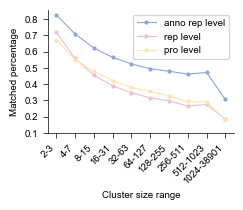

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")

fig, ax = plt.subplots(figsize=(2.4, 1.6))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(df['bin_idx'], ["-".join([str(j) for j in bins[i]]) for i in df['bin_idx']], rotation=45, ha='right')

plt.plot(df['bin_idx'], df['anno_rep_pred_ratio'], markersize=2, marker='o')
plt.plot(df['bin_idx'], df['rep_pred_ratio'], markersize=2, marker='o')
plt.plot(df['bin_idx'], df['pro_pred_ratio'], markersize=2, marker='o')
plt.yticks(np.linspace(0.1, 0.8, 8))

plt.ylabel("Matched percentage")
plt.xlabel("Cluster size range")
plt.legend(
    labels=[# 'total protein',
            'anno rep level',
            'rep level',
            'pro level'],
    loc='upper right',
    bbox_to_anchor=(1,1)
)

fig.savefig(fig_file, bbox_inches="tight", transparent=True)